# Yambda-50M: Загрузка, предобработка и первые гипотезы

**Гипотезы в этом ноутбуке:**
- **H1** — Вероятность дослушивания (Listen+) ниже для рекомендательных треков
- **H2** — Вероятность дизлайка выше для рекомендательных треков

**Порядок работы:**
1. Загрузка данных с HuggingFace
2. Предобработка (время, флаги, нормировка)
3. EDA — разведочный анализ
4. Тест H1
5. Тест H2

---
## 0. Импорты и настройки

In [2]:
pip install pandas scipy matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.0/36.5 MB 7.1 MB/s eta 0:00:05
   -- ------------------------------------- 1.8/36.5 MB 5.9 MB/s eta 0:00:06
   ------ --------------------------------- 5.8/36.5 MB 10.1 MB/s eta 0:00:04
   ------- -------------------------------- 6.6/36.5 MB 10.3 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/36.5 MB 8.7 MB/s eta 0:00:04
   ---------- ----------------------------- 10.0/36.5 MB 8.3 MB/s eta 0:00:04
   ------------ --------------------------- 11.3/36.5 MB 8.0 MB/s eta 0:00:04
   -------------- ------------------------- 12.8/36.5 MB 7.7 MB/s eta 0:00:04
   --------------- ------------------------ 14.2/36.5 MB 7.7 MB/s eta 0:00:03
   ---------------- -------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Стиль графиков
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})
sns.set_palette('Set2')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Метки для графиков
ORGANIC_LABELS = {0: 'Рекомендательные (is_organic=0)', 1: 'Органические (is_organic=1)'}
COLORS = {0: '#E07B54', 1: '#5B8DB8'}

print(' Импорты выполнены')

✅ Импорты выполнены


In [5]:
from datasets import load_dataset, DatasetDict

def load_yambda(event_type: str, size: str = '50m') -> pd.DataFrame:
    """
    Загружает один тип событий из Yambda и возвращает pandas DataFrame.
    event_type: 'listens', 'likes', 'dislikes', 'unlikes', 'undislikes', 'multi_event'
    size: '50m', '500m', '5b'
    """
    print(f'  Загрузка {event_type} (yambda-{size})...')
    data = load_dataset(
        'yandex/yambda',
        data_dir=f'flat/{size}',
        data_files=f'{event_type}.parquet'
    )
    assert isinstance(data, DatasetDict)
    df = data['train'].to_pandas()
    print(f' {event_type}: {len(df):,} строк, {df["uid"].nunique():,} пользователей')
    return df

print(' Загружаем данные...')
listens  = load_yambda('listens')
dislikes = load_yambda('dislikes')
likes    = load_yambda('likes')
print('\n Все файлы загружены!')

📥 Загружаем данные...
  Загрузка listens (yambda-50m)...


Generating train split: 46467212 examples [00:03, 14347138.54 examples/s]


  ✅ listens: 46,467,212 строк, 9,238 пользователей
  Загрузка dislikes (yambda-50m)...


Generating train split: 107776 examples [00:00, 9775432.13 examples/s]


  ✅ dislikes: 107,776 строк, 5,951 пользователей
  Загрузка likes (yambda-50m)...


Generating train split: 881456 examples [00:00, 16635818.64 examples/s]

  ✅ likes: 881,456 строк, 8,283 пользователей

🎉 Все файлы загружены!


In [6]:
print('=== LISTENS ===')
print(listens.dtypes)
print()
listens.head(3)

=== LISTENS ===
uid                     uint32
timestamp               uint32
item_id                 uint32
is_organic               uint8
played_ratio_pct        uint16
track_length_seconds    uint32
dtype: object



,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds
0,100,39420,8326270,0,100,170
1,100,39420,1441281,0,100,105
2,100,39625,286361,0,100,185


In [7]:
print('=== DISLIKES ===')
dislikes.head(3)

=== DISLIKES ===


,uid,timestamp,item_id,is_organic
0,100,3087560,9170134,1
1,100,3936560,8661238,1
2,100,20432825,4927727,1


In [8]:
# Базовая статистика по listens
print(' Статистика listens:')
print(f"  Всего прослушиваний:     {len(listens):>12,}")
print(f"  Уникальных пользователей:{listens['uid'].nunique():>12,}")
print(f"  Уникальных треков:       {listens['item_id'].nunique():>12,}")
print(f"  Органических (is_organic=1): {listens['is_organic'].sum():>9,} ({listens['is_organic'].mean()*100:.1f}%)")
print(f"  Рекомендательных (is_organic=0): {(listens['is_organic']==0).sum():>5,} ({(listens['is_organic']==0).mean()*100:.1f}%)")
print()
print(' played_ratio_pct:')
print(listens['played_ratio_pct'].describe().round(1))
print(f"\n  Значений > 100%: {(listens['played_ratio_pct'] > 100).sum():,} ({(listens['played_ratio_pct'] > 100).mean()*100:.2f}%)")

📊 Статистика listens:
  Всего прослушиваний:       46,467,212
  Уникальных пользователей:       9,238
  Уникальных треков:            877,168
  Органических (is_organic=1): 24,003,657 (51.7%)
  Рекомендательных (is_organic=0): 22,463,555 (48.3%)

📊 played_ratio_pct:
count    46467212.0
mean           64.8
std            44.1
min             0.0
25%             7.0
50%           100.0
75%           100.0
max           159.0
Name: played_ratio_pct, dtype: float64

  Значений > 100%: 218,145 (0.47%)


---
## 3. Предобработка

### 3.1 Реконструкция абсолютного времени

`timestamp` в датасете — это **дельта-времена**, бинированные в 5-секундные единицы, отсортированные по `(uid, timestamp)`.
Для работы с временными окнами нужно восстановить накопленное время.

In [9]:
def reconstruct_time(df: pd.DataFrame) -> pd.DataFrame:
    """
    Восстанавливает накопленное время из дельта-таймстемпов.
    Добавляет колонку abs_time_sec — относительное время от первого события uid в секундах.
    """
    df = df.sort_values(['uid', 'timestamp']).copy()
    # cumsum дельт по каждому пользователю × 5 секунд
    df['abs_time_sec'] = df.groupby('uid')['timestamp'].cumsum() * 5
    return df

listens  = reconstruct_time(listens)
dislikes = reconstruct_time(dislikes)
likes    = reconstruct_time(likes)

print(' Время реконструировано')
print('Пример (первые 3 строки одного пользователя):')
uid_example = listens['uid'].iloc[0]
listens[listens['uid'] == uid_example][['uid', 'timestamp', 'abs_time_sec', 'is_organic', 'played_ratio_pct']].head(3)

✅ Время реконструировано
Пример (первые 3 строки одного пользователя):


,uid,timestamp,abs_time_sec,is_organic,played_ratio_pct
0,100,39420,197100,0,100
1,100,39420,394200,0,100
2,100,39625,592325,0,100


### 3.2 Добавляем флаг Listen+ (H1)

**Listen+** = трек считается прослушанным, если `played_ratio_pct ≥ 50`.
Значения `> 100` — валидные события (перемотка/повтор), включаем как Listen+.

In [10]:
listens['listen_plus'] = (listens['played_ratio_pct'] >= 50).astype(int)

print(' Флаг listen_plus добавлен')
print(f"Listen+ = 1: {listens['listen_plus'].sum():,} ({listens['listen_plus'].mean()*100:.1f}%)")
print(f"Listen+ = 0: {(listens['listen_plus']==0).sum():,} ({(listens['listen_plus']==0).mean()*100:.1f}%)")

✅ Флаг listen_plus добавлен
Listen+ = 1: 29,439,278 (63.4%)
Listen+ = 0: 17,027,934 (36.6%)


### 3.3 Бакеты длины трека (для контроля confounding в H1, H5)

Длина трека — confounding-переменная: длинные треки реже дослушиваются независимо от типа взаимодействия.

In [11]:
bins   = [0, 120, 240, 420, np.inf]   # секунды
labels = ['0–2 мин', '2–4 мин', '4–7 мин', '7+ мин']

listens['length_bucket'] = pd.cut(
    listens['track_length_seconds'],
    bins=bins, labels=labels, right=False
)

print(' Бакеты длины трека добавлены:')
print(listens['length_bucket'].value_counts().sort_index())

✅ Бакеты длины трека добавлены:
length_bucket
0–2 мин     1790154
2–4 мин    34304028
4–7 мин     9849602
7+ мин       523428
Name: count, dtype: int64


### 3.4 Проверка пропусков

In [12]:
print('Пропуски в listens:')
print(listens.isnull().sum())
print()
# played_ratio_pct может быть null — проверим
null_ratio = listens['played_ratio_pct'].isnull().sum()
if null_ratio > 0:
    print(f'⚠️  played_ratio_pct: {null_ratio:,} пропусков — исключаем из анализа H1')
    listens_h1 = listens.dropna(subset=['played_ratio_pct']).copy()
else:
    print(' Пропусков нет')
    listens_h1 = listens.copy()

Пропуски в listens:
uid                     0
timestamp               0
item_id                 0
is_organic              0
played_ratio_pct        0
track_length_seconds    0
abs_time_sec            0
listen_plus             0
length_bucket           0
dtype: int64

✅ Пропусков нет


EDA

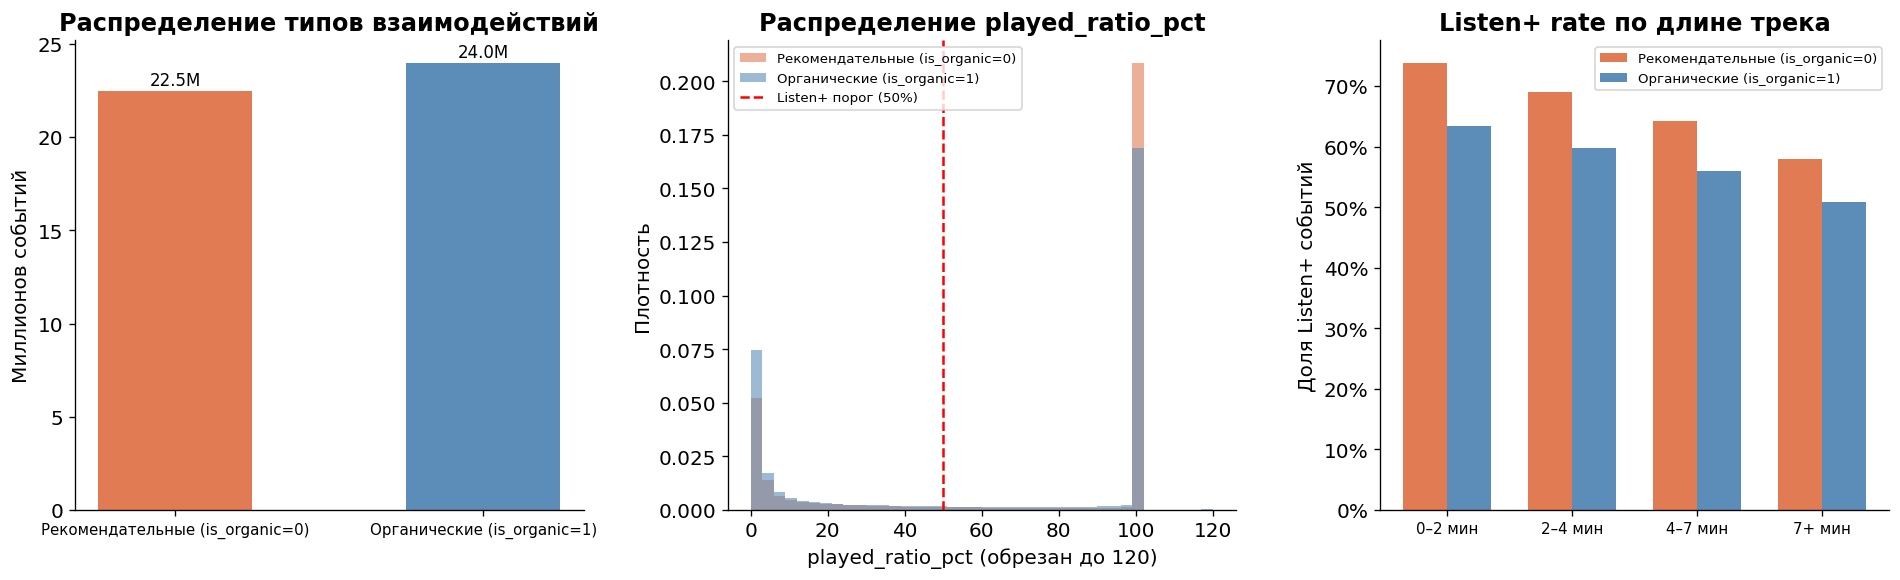

💾 График сохранён: eda_overview.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Распределение is_organic
organic_counts = listens['is_organic'].value_counts().sort_index()
bars = axes[0].bar(
    [ORGANIC_LABELS[k] for k in organic_counts.index],
    organic_counts.values / 1e6,
    color=[COLORS[k] for k in organic_counts.index],
    width=0.5
)
axes[0].set_title('Распределение типов взаимодействий', fontweight='bold')
axes[0].set_ylabel('Миллионов событий')
axes[0].tick_params(axis='x', labelsize=9)
for bar, val in zip(bars, organic_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val/1e6:.1f}M', ha='center', fontsize=10)

# 2. Распределение played_ratio_pct по группам
for org, label in ORGANIC_LABELS.items():
    subset = listens_h1[listens_h1['is_organic'] == org]['played_ratio_pct'].clip(0, 120)
    axes[1].hist(subset, bins=40, alpha=0.6, label=label, color=COLORS[org], density=True)
axes[1].axvline(50, color='red', linestyle='--', linewidth=1.5, label='Listen+ порог (50%)')
axes[1].set_title('Распределение played_ratio_pct', fontweight='bold')
axes[1].set_xlabel('played_ratio_pct (обрезан до 120)')
axes[1].set_ylabel('Плотность')
axes[1].legend(fontsize=8)

# 3. Listen+ rate по бакетам длины
bucket_organic = listens_h1.groupby(['length_bucket', 'is_organic'])['listen_plus'].mean().unstack()
x = np.arange(len(bucket_organic))
width = 0.35
if 0 in bucket_organic.columns:
    axes[2].bar(x - width/2, bucket_organic[0], width, label=ORGANIC_LABELS[0], color=COLORS[0])
if 1 in bucket_organic.columns:
    axes[2].bar(x + width/2, bucket_organic[1], width, label=ORGANIC_LABELS[1], color=COLORS[1])
axes[2].set_xticks(x)
axes[2].set_xticklabels(bucket_organic.index, fontsize=9)
axes[2].set_title('Listen+ rate по длине трека', fontweight='bold')
axes[2].set_ylabel('Доля Listen+ событий')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print(' График сохранён: eda_overview.png')

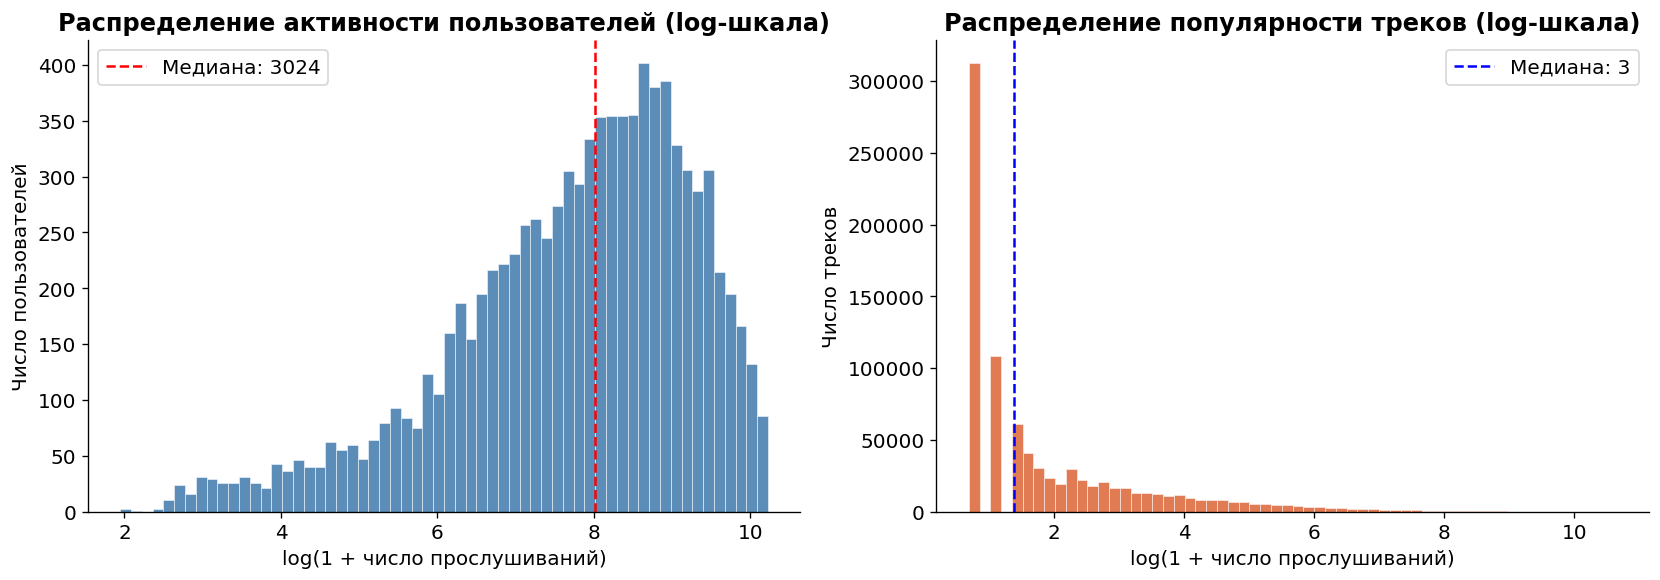

In [14]:
# Активность пользователей и треков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

user_activity = listens.groupby('uid').size()
item_activity = listens.groupby('item_id').size()

axes[0].hist(np.log1p(user_activity), bins=60, color='#5B8DB8', edgecolor='white', linewidth=0.3)
axes[0].set_title('Распределение активности пользователей (log-шкала)', fontweight='bold')
axes[0].set_xlabel('log(1 + число прослушиваний)')
axes[0].set_ylabel('Число пользователей')
axes[0].axvline(np.log1p(user_activity.median()), color='red', linestyle='--',
                label=f'Медиана: {user_activity.median():.0f}')
axes[0].legend()

axes[1].hist(np.log1p(item_activity), bins=60, color='#E07B54', edgecolor='white', linewidth=0.3)
axes[1].set_title('Распределение популярности треков (log-шкала)', fontweight='bold')
axes[1].set_xlabel('log(1 + число прослушиваний)')
axes[1].set_ylabel('Число треков')
axes[1].axvline(np.log1p(item_activity.median()), color='blue', linestyle='--',
                label=f'Медиана: {item_activity.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

---
## 5. H1 — Вероятность Listen+ ниже для рекомендательных треков

**Улучшенная формулировка:**
Вероятность Listen+ (played_ratio_pct ≥ 50%, включая >100%) значимо ниже для рекомендательных прослушиваний (is_organic=0), чем для органических (is_organic=1), **при контроле длины трека**.

**Статистический тест:** Mann-Whitney U (данные не нормальны, N большой)
**Effect size:** rank-biserial correlation

In [15]:
# ── Основные метрики ──────────────────────────────────────────────────────────
h1_summary = listens_h1.groupby('is_organic').agg(
    total_listens       = ('listen_plus', 'count'),
    listen_plus_count   = ('listen_plus', 'sum'),
    listen_plus_rate    = ('listen_plus', 'mean'),
    mean_ratio          = ('played_ratio_pct', 'mean'),
    median_ratio        = ('played_ratio_pct', 'median'),
).round(4)
h1_summary.index = h1_summary.index.map(ORGANIC_LABELS)

print(' H1 — Основные метрики:')
print(h1_summary.to_string())

📊 H1 — Основные метрики:
                                 total_listens  listen_plus_count  listen_plus_rate  mean_ratio  median_ratio
is_organic                                                                                                   
Рекомендательные (is_organic=0)       22463555           15317548            0.6819     69.6054         100.0
Органические (is_organic=1)           24003657           14121730            0.5883     60.2245          99.0


In [16]:
# ── Mann-Whitney U тест ───────────────────────────────────────────────────────
rec_ratio  = listens_h1[listens_h1['is_organic'] == 0]['played_ratio_pct'].values
org_ratio  = listens_h1[listens_h1['is_organic'] == 1]['played_ratio_pct'].values

# Для больших выборок — сэмплируем (тест занимает долго на 40M+ строках)
SAMPLE_SIZE = 500_000
if len(rec_ratio) > SAMPLE_SIZE or len(org_ratio) > SAMPLE_SIZE:
    rng = np.random.default_rng(RANDOM_SEED)
    rec_sample = rng.choice(rec_ratio, size=min(SAMPLE_SIZE, len(rec_ratio)), replace=False)
    org_sample = rng.choice(org_ratio, size=min(SAMPLE_SIZE, len(org_ratio)), replace=False)
    print(f'⚠️  Используем сэмпл {SAMPLE_SIZE:,} на группу для Mann-Whitney')
else:
    rec_sample, org_sample = rec_ratio, org_ratio

stat, p_value = mannwhitneyu(rec_sample, org_sample, alternative='less')

# Rank-biserial correlation (effect size)
n1, n2 = len(rec_sample), len(org_sample)
r_rb = 1 - (2 * stat) / (n1 * n2)   # от -1 до +1; <0 → рек ниже

print('\n Статистический тест (Mann-Whitney U):')
print(f'  H0: played_ratio_pct рекомендательных ≥ органических')
print(f'  H1: played_ratio_pct рекомендательных < органических')
print(f'  U-statistic:         {stat:.2e}')
print(f'  p-value:             {p_value:.4e}')
print(f'  Rank-biserial r:     {r_rb:.4f}  (|r|<0.1 малый, 0.1–0.3 средний, >0.3 большой)')

if p_value < 0.05:
    print(f'\n Результат: H1 ПОДТВЕРЖДАЕТСЯ (p < 0.05)')
    print(f'   Рекомендательные треки дослушиваются реже.')
else:
    print(f'\n Результат: H1 НЕ ПОДТВЕРЖДАЕТСЯ (p = {p_value:.4f})')

⚠️  Используем сэмпл 500,000 на группу для Mann-Whitney

📐 Статистический тест (Mann-Whitney U):
  H0: played_ratio_pct рекомендательных ≥ органических
  H1: played_ratio_pct рекомендательных < органических
  U-statistic:         1.39e+11
  p-value:             1.0000e+00
  Rank-biserial r:     -0.1150  (|r|<0.1 малый, 0.1–0.3 средний, >0.3 большой)

❌ Результат: H1 НЕ ПОДТВЕРЖДАЕТСЯ (p = 1.0000)


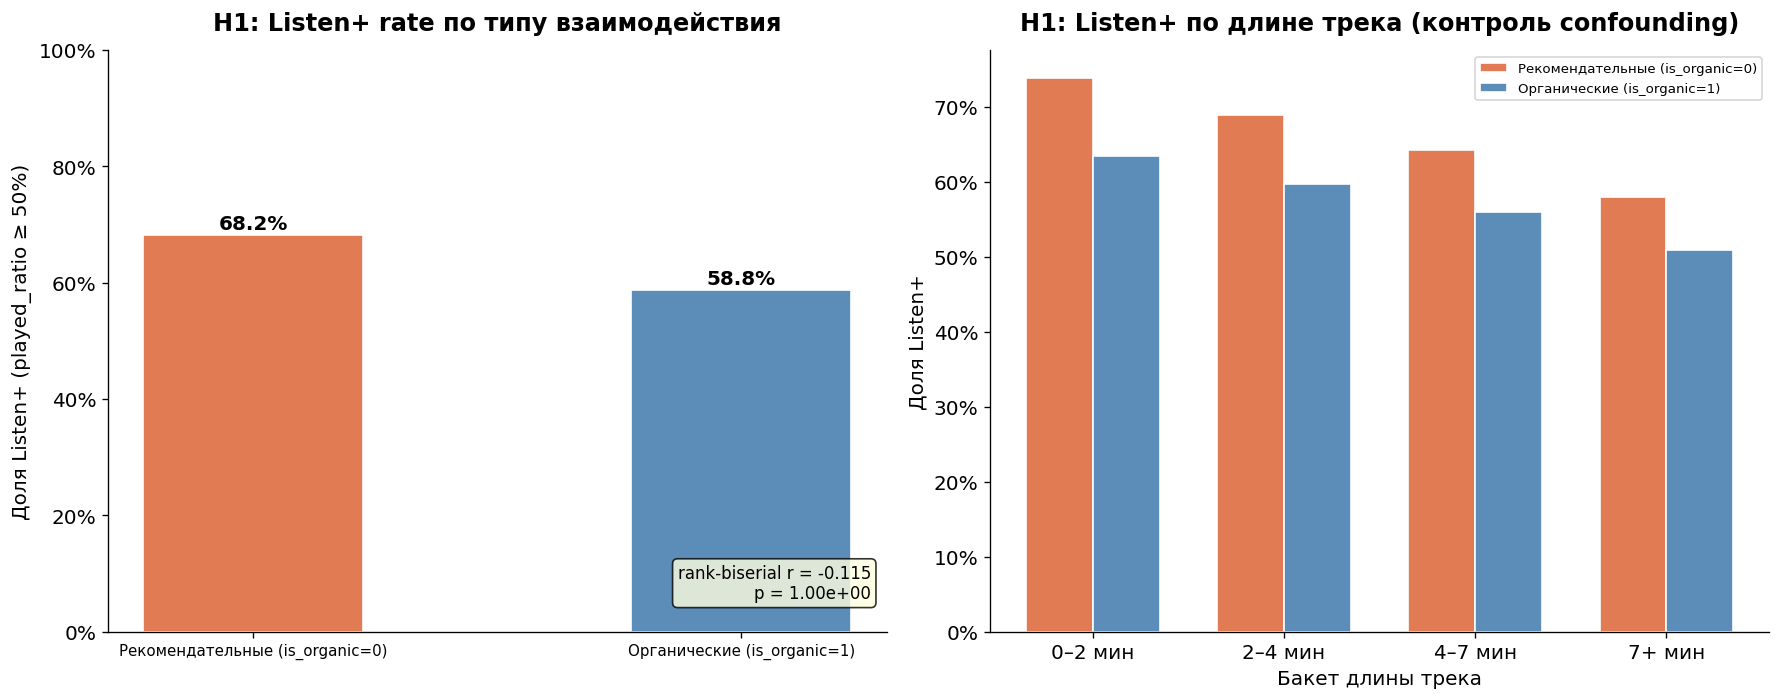

💾 График сохранён: h1_results.png


In [17]:
# ── Визуализация H1 ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Listen+ rate overall
h1_data = listens_h1.groupby('is_organic')['listen_plus'].mean()
bars = axes[0].bar(
    [ORGANIC_LABELS[k] for k in h1_data.index],
    h1_data.values,
    color=[COLORS[k] for k in h1_data.index],
    width=0.45, edgecolor='white'
)
axes[0].set_title('H1: Listen+ rate по типу взаимодействия', fontweight='bold', pad=12)
axes[0].set_ylabel('Доля Listen+ (played_ratio ≥ 50%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', labelsize=9)
for bar, val in zip(bars, h1_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')
# Аннотация effect size
axes[0].text(0.98, 0.05, f'rank-biserial r = {r_rb:.3f}\np = {p_value:.2e}',
             transform=axes[0].transAxes, ha='right', va='bottom',
             fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 2: Listen+ по бакетам длины (grouped bar)
lp_by_bucket = listens_h1.groupby(['length_bucket', 'is_organic'])['listen_plus'].mean().unstack()
x = np.arange(len(lp_by_bucket))
w = 0.35
if 0 in lp_by_bucket.columns:
    bars0 = axes[1].bar(x - w/2, lp_by_bucket[0], w, label=ORGANIC_LABELS[0],
                        color=COLORS[0], edgecolor='white')
if 1 in lp_by_bucket.columns:
    bars1 = axes[1].bar(x + w/2, lp_by_bucket[1], w, label=ORGANIC_LABELS[1],
                        color=COLORS[1], edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(lp_by_bucket.index)
axes[1].set_title('H1: Listen+ по длине трека (контроль confounding)', fontweight='bold', pad=12)
axes[1].set_ylabel('Доля Listen+')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_xlabel('Бакет длины трека')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('h1_results.png', bbox_inches='tight')
plt.show()
print('График сохранён: h1_results.png')

---
## 6. H2 — Вероятность дизлайка выше для рекомендательных треков

**Улучшенная формулировка:**
P(dislike | listen, is_organic=0) > P(dislike | listen, is_organic=1)
где **знаменатель — количество прослушиваний** в группе (нормировка обязательна).

**Алгоритм:**
1. Считаем число прослушиваний по `(uid, item_id, is_organic)`
2. Джойним с dislikes по `(uid, item_id)`
3. Флаг «был ли дизлайк» на уровне `(uid, item_id)`
4. P(dislike) = count(дизлайкнутых пар) / count(прослушанных пар)

**Статистический тест:** Chi-squared + Bootstrap 95% CI для разницы вероятностей

In [18]:
# ── Подготовка: агрегат прослушиваний по (uid, item_id) ──────────────────────
# Берём is_organic от последнего прослушивания (можно обсудить)
listen_agg = (
    listens
    .groupby(['uid', 'item_id'])
    .agg(
        n_listens   = ('listen_plus', 'count'),
        is_organic  = ('is_organic', 'last'),    # тип последнего прослушивания
        listen_plus = ('listen_plus', 'max'),
    )
    .reset_index()
)

# Флаг дизлайка на уровне (uid, item_id)
dislike_flag = dislikes[['uid', 'item_id']].drop_duplicates()
dislike_flag['disliked'] = 1

# Джойн
h2_df = listen_agg.merge(dislike_flag, on=['uid', 'item_id'], how='left')
h2_df['disliked'] = h2_df['disliked'].fillna(0).astype(int)

print(f'Объединено: {len(h2_df):,} пар (uid, item_id)')
print(f'   Из них с дизлайком: {h2_df["disliked"].sum():,} ({h2_df["disliked"].mean()*100:.2f}%)')
print(f'   Органических пар:         {(h2_df["is_organic"]==1).sum():,}')
print(f'   Рекомендательных пар:     {(h2_df["is_organic"]==0).sum():,}')

✅ Объединено: 13,268,889 пар (uid, item_id)
   Из них с дизлайком: 85,345 (0.64%)
   Органических пар:         4,806,250
   Рекомендательных пар:     8,462,639


In [19]:
# ── Основные метрики H2 ───────────────────────────────────────────────────────
h2_summary = h2_df.groupby('is_organic').agg(
    pairs_total    = ('disliked', 'count'),
    disliked_count = ('disliked', 'sum'),
    dislike_rate   = ('disliked', 'mean'),
).round(6)
h2_summary.index = h2_summary.index.map(ORGANIC_LABELS)

print('H2 — P(dislike | listen) по группам:')
print(h2_summary.to_string())

📊 H2 — P(dislike | listen) по группам:
                                 pairs_total  disliked_count  dislike_rate
is_organic                                                                
Рекомендательные (is_organic=0)      8462639           60375      0.007134
Органические (is_organic=1)          4806250           24970      0.005195


In [20]:
# ── Chi-squared тест ──────────────────────────────────────────────────────────
ct = pd.crosstab(h2_df['is_organic'], h2_df['disliked'])
chi2, p_chi2, dof, expected = chi2_contingency(ct)

# Odds ratio
# ct.iloc[0] = рекомендательные, ct.iloc[1] = органические
or_rec  = ct.iloc[0, 1] / ct.iloc[0, 0] if ct.iloc[0, 0] > 0 else np.nan  # dislike/no-dislike для rec
or_org  = ct.iloc[1, 1] / ct.iloc[1, 0] if ct.iloc[1, 0] > 0 else np.nan
odds_ratio = or_rec / or_org if or_org > 0 else np.nan

print('Chi-squared тест:')
print(f'  χ² = {chi2:.2f},  p = {p_chi2:.4e},  df = {dof}')
print(f'  Odds Ratio (рек / орг): {odds_ratio:.4f}')
print(f'  (OR > 1 → рекомендательные дизлайкают чаще)')

if p_chi2 < 0.05:
    print(f'\n Результат: H2 ПОДТВЕРЖДАЕТСЯ (p < 0.05)')
    direction = 'выше' if odds_ratio > 1 else 'ниже'
    print(f'   P(dislike) для рекомендательных {direction} (OR = {odds_ratio:.3f})')
else:
    print(f'\n Результат: H2 НЕ ПОДТВЕРЖДАЕТСЯ (p = {p_chi2:.4f})')

📐 Chi-squared тест:
  χ² = 1803.06,  p = 0.0000e+00,  df = 1
  Odds Ratio (рек / орг): 1.3759
  (OR > 1 → рекомендательные дизлайкают чаще)

✅ Результат: H2 ПОДТВЕРЖДАЕТСЯ (p < 0.05)
   P(dislike) для рекомендательных выше (OR = 1.376)


In [21]:
# ── Bootstrap 95% CI для разницы P(dislike) ───────────────────────────────────
N_BOOTSTRAP = 2000
rng = np.random.default_rng(RANDOM_SEED)

rec_disliked = h2_df[h2_df['is_organic'] == 0]['disliked'].values
org_disliked = h2_df[h2_df['is_organic'] == 1]['disliked'].values

diffs = []
for _ in range(N_BOOTSTRAP):
    r = rng.choice(rec_disliked, size=len(rec_disliked), replace=True).mean()
    o = rng.choice(org_disliked, size=len(org_disliked), replace=True).mean()
    diffs.append(r - o)

ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
obs_diff = rec_disliked.mean() - org_disliked.mean()

print(f'\n Bootstrap 95% CI для P(dislike|rec) - P(dislike|org):')
print(f'  Наблюдаемая разница: {obs_diff:+.6f}')
print(f'  95% CI:              [{ci_low:+.6f}, {ci_high:+.6f}]')
if ci_low > 0:
    print(f'  → CI не содержит 0: разница значима, рекомендательные дизлайкают ЧАЩЕ')
elif ci_high < 0:
    print(f'  → CI не содержит 0: разница значима, рекомендательные дизлайкают РЕЖЕ')
else:
    print(f'  → CI содержит 0: разница статистически незначима')


📐 Bootstrap 95% CI для P(dislike|rec) - P(dislike|org):
  Наблюдаемая разница: +0.001939
  95% CI:              [+0.001855, +0.002025]
  → CI не содержит 0: разница значима, рекомендательные дизлайкают ЧАЩЕ


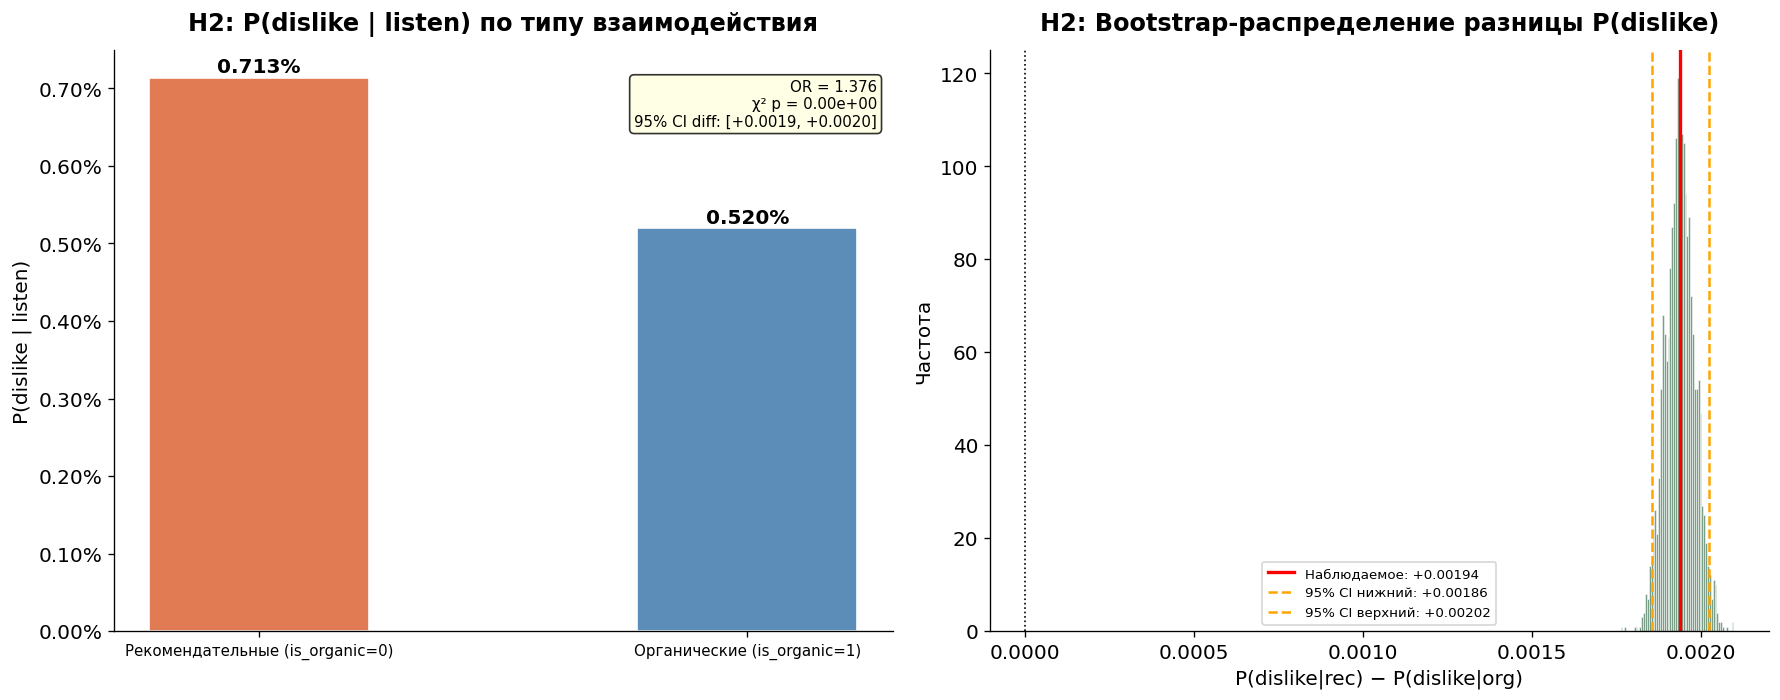

💾 График сохранён: h2_results.png


In [22]:
# ── Визуализация H2 ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: P(dislike) по группам с CI
groups   = [ORGANIC_LABELS[0], ORGANIC_LABELS[1]]
rates    = [rec_disliked.mean(), org_disliked.mean()]
ci_sizes = [obs_diff - ci_low, ci_high - obs_diff]   # приближённо для рек

bars = axes[0].bar(groups, rates,
                   color=[COLORS[0], COLORS[1]],
                   width=0.45, edgecolor='white')
axes[0].set_title('H2: P(dislike | listen) по типу взаимодействия', fontweight='bold', pad=12)
axes[0].set_ylabel('P(dislike | listen)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', labelsize=9)
for bar, val in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rates)*0.01,
                 f'{val*100:.3f}%', ha='center', fontweight='bold')
axes[0].text(0.98, 0.95,
             f'OR = {odds_ratio:.3f}\nχ² p = {p_chi2:.2e}\n95% CI diff: [{ci_low:+.4f}, {ci_high:+.4f}]',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 2: Bootstrap-распределение разницы
axes[1].hist(diffs, bins=60, color='#7B9E87', edgecolor='white', linewidth=0.3)
axes[1].axvline(obs_diff, color='red', linewidth=2, label=f'Наблюдаемое: {obs_diff:+.5f}')
axes[1].axvline(ci_low,  color='orange', linestyle='--', linewidth=1.5, label=f'95% CI нижний: {ci_low:+.5f}')
axes[1].axvline(ci_high, color='orange', linestyle='--', linewidth=1.5, label=f'95% CI верхний: {ci_high:+.5f}')
axes[1].axvline(0, color='black', linewidth=1, linestyle=':')
axes[1].set_title('H2: Bootstrap-распределение разницы P(dislike)', fontweight='bold', pad=12)
axes[1].set_xlabel('P(dislike|rec) − P(dislike|org)')
axes[1].set_ylabel('Частота')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('h2_results.png', bbox_inches='tight')
plt.show()
print('График сохранён: h2_results.png')